MUESTRAS GENERADAS (NOM-021-RECNAT-2000)
         pH  MateriaOrganica          N          P           K    Humedad  \
0  5.998160         7.311994   7.842495  23.982967   67.301818  14.091431   
1  8.302857         2.296714  34.224505  18.076915   98.005295  42.894124   
2  7.427976         1.586712  34.734932  14.453994   69.562936  31.969782   
3  6.894634         4.170896  40.058645  27.471568   44.836709  21.721697   
4  5.124075         7.892378  44.935023   6.002332   53.778044  14.874523   
5  5.123978         2.315415  58.671864  16.300878  149.018055  37.790882   
6  4.732334         5.541017  33.396519   3.306548   77.773441  31.702546   
7  7.964705         6.212147  22.762606  15.653837  121.995561  28.671138   
8  6.904460         2.282282  48.735241   4.520188  160.956836  41.286240   
9  7.332290         5.961623  19.895774   6.208084  213.310552  37.600902   

  Fertilidad  
0       Baja  
1       Baja  
2      Media  
3       Alta  
4       Baja  
5      Media  
6     

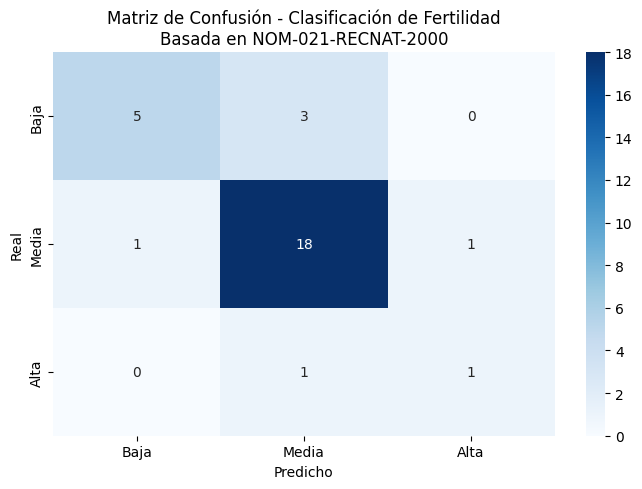


PREDICCIONES DE EJEMPLO
Suelo rico (ideal): Media
Suelo pobre (degradado): Baja
Suelo medio (típico): Media
Suelo ácido norte: Media
Suelo alcalino: Baja

✅ Dataset guardado como 'suelos_nom021.csv'
📥 Descárgalo haciendo clic en la carpeta de la izquierda (📁) o ejecutando:
   files.download('suelos_nom021.csv')


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [1]:
# ======================================================
# SUELO INTELIGENTE - Clasificador de Fertilidad
# Basado en NOM-021-RECNAT-2000 (Semarnat, 2002)
# Autor: Luis Triche
# Fecha: 28 abril 2026
# ======================================================

# 1. Importar librerías
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# ======================================================
# 2. Parámetros según NOM-021-RECNAT-2000
# Rangos realistas para suelos agrícolas de México
# ======================================================

rangos_nom = {
    'pH': (4.5, 8.5),           # Ácido a alcalino
    'MateriaOrganica': (0.5, 8.0),   # % (bajo a muy alto)
    'N': (5, 60),               # Nitrógeno ppm (bajo a alto)
    'P': (3, 30),               # Fósforo ppm (Olsen)
    'K': (20, 300),             # Potasio ppm (bajo a muy alto)
    'Humedad': (10, 45)         # % humedad (seco a húmedo)
}

# 3. Generar dataset sintético con rangos NOM-021
np.random.seed(42)  # Para que sea reproducible
n = 150              # 150 muestras (más robusto)

df = pd.DataFrame({
    'pH': np.random.uniform(rangos_nom['pH'][0], rangos_nom['pH'][1], n),
    'MateriaOrganica': np.random.uniform(rangos_nom['MateriaOrganica'][0], rangos_nom['MateriaOrganica'][1], n),
    'N': np.random.uniform(rangos_nom['N'][0], rangos_nom['N'][1], n),
    'P': np.random.uniform(rangos_nom['P'][0], rangos_nom['P'][1], n),
    'K': np.random.uniform(rangos_nom['K'][0], rangos_nom['K'][1], n),
    'Humedad': np.random.uniform(rangos_nom['Humedad'][0], rangos_nom['Humedad'][1], n)
})

# ======================================================
# 4. Función de fertilidad según NOM-021-RECNAT-2000
# Criterios de puntaje basados en niveles críticos
# ======================================================

def fertilidad_nom(fila):
    score = 0

    # pH (óptimo 6.0-7.5 según NOM)
    if 6.0 <= fila['pH'] <= 7.5:
        score += 1
    elif 5.5 <= fila['pH'] < 6.0 or 7.5 < fila['pH'] <= 8.0:
        score += 0.5  # marginal

    # Materia Orgánica (alto > 4%, medio 2-4%, bajo <2%)
    if fila['MateriaOrganica'] > 4.0:
        score += 1
    elif fila['MateriaOrganica'] > 2.0:
        score += 0.5

    # Nitrógeno (alto > 30 ppm)
    if fila['N'] > 30:
        score += 1
    elif fila['N'] > 15:
        score += 0.5

    # Fósforo (Olsen: alto > 20 ppm, medio 10-20)
    if fila['P'] > 20:
        score += 1
    elif fila['P'] > 10:
        score += 0.5

    # Potasio (alto > 200 ppm, medio 100-200)
    if fila['K'] > 200:
        score += 1
    elif fila['K'] > 100:
        score += 0.5

    # Humedad (óptimo 20-35% para mayoría de cultivos)
    if 20 <= fila['Humedad'] <= 35:
        score += 1
    elif 15 <= fila['Humedad'] < 20 or 35 < fila['Humedad'] <= 40:
        score += 0.5

    # Clasificación final según puntaje
    if score >= 5.0:
        return 'Alta'
    elif score >= 3.0:
        return 'Media'
    else:
        return 'Baja'

df['Fertilidad'] = df.apply(fertilidad_nom, axis=1)

print("=" * 50)
print("MUESTRAS GENERADAS (NOM-021-RECNAT-2000)")
print("=" * 50)
print(df.head(10))
print(f"\nDistribución de fertilidad:")
print(df['Fertilidad'].value_counts())

# ======================================================
# 5. Ver valores atípicos (fuera de rangos NOM)
# ======================================================

def validar_nom(fila):
    errores = []
    if fila['pH'] < 4.0 or fila['pH'] > 9.0:
        errores.append('pH fuera de rango')
    if fila['MateriaOrganica'] < 0.2 or fila['MateriaOrganica'] > 15:
        errores.append('MO fuera de rango')
    if fila['N'] < 2 or fila['N'] > 100:
        errores.append('N fuera de rango')
    if fila['P'] < 1 or fila['P'] > 50:
        errores.append('P fuera de rango')
    if fila['K'] < 10 or fila['K'] > 500:
        errores.append('K fuera de rango')
    return len(errores) == 0

df['valido_nom'] = df.apply(validar_nom, axis=1)
print(f"\nMuestras válidas según NOM-021: {df['valido_nom'].sum()} de {len(df)}")
if not df['valido_nom'].all():
    print("⚠️ Hay muestras fuera de rango. Se recomienda revisar.")

# Opcional: filtrar solo muestras válidas
df = df[df['valido_nom']].drop('valido_nom', axis=1)

# ======================================================
# 6. Preprocesamiento y modelo
# ======================================================

X = df.drop('Fertilidad', axis=1)
y = df['Fertilidad']

# Dividir en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Estandarizar (StandardScaler)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Entrenar KNN con k=5 (más robusto que k=3)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

# Predecir y evaluar
y_pred = knn.predict(X_test_scaled)
matriz = confusion_matrix(y_test, y_pred, labels=['Baja', 'Media', 'Alta'])
exactitud = accuracy_score(y_test, y_pred)

print("\n" + "=" * 50)
print("RESULTADOS DEL MODELO")
print("=" * 50)
print(f"Exactitud (Accuracy): {exactitud:.2%}")
print("\nMatriz de Confusión:")
print(pd.DataFrame(matriz, index=['Real Baja', 'Real Media', 'Real Alta'],
                   columns=['Pred Baja', 'Pred Media', 'Pred Alta']))

# ======================================================
# 7. Visualización de Matriz de Confusión
# ======================================================
plt.figure(figsize=(7,5))
sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Baja', 'Media', 'Alta'],
            yticklabels=['Baja', 'Media', 'Alta'])
plt.title('Matriz de Confusión - Clasificación de Fertilidad\nBasada en NOM-021-RECNAT-2000')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

# ======================================================
# 8. Función para clasificar nuevas muestras
# ======================================================

def predecir_fertilidad(pH, materia_organica, N, P, K, humedad):
    """
    Clasifica la fertilidad de una parcela según NOM-021-RECNAT-2000.

    Parámetros:
    pH (float): entre 4.5 y 8.5
    materia_organica (float): % de materia orgánica (0.5-8.0)
    N (float): Nitrógeno en ppm (5-60)
    P (float): Fósforo en ppm (3-30)
    K (float): Potasio en ppm (20-300)
    humedad (float): % de humedad (10-45)

    Retorna:
    str: 'Baja', 'Media' o 'Alta'
    """
    nueva = np.array([[pH, materia_organica, N, P, K, humedad]])
    nueva_scaled = scaler.transform(nueva)
    prediccion = knn.predict(nueva_scaled)
    return prediccion[0]

# ======================================================
# 9. Ejemplos de predicción con valores realistas
# ======================================================
print("\n" + "=" * 50)
print("PREDICCIONES DE EJEMPLO")
print("=" * 50)

ejemplos = [
    {"nombre": "Suelo rico (ideal)", "valores": (6.8, 4.5, 45, 25, 240, 30)},
    {"nombre": "Suelo pobre (degradado)", "valores": (5.2, 1.2, 10, 5, 45, 18)},
    {"nombre": "Suelo medio (típico)", "valores": (6.5, 2.8, 28, 14, 130, 25)},
    {"nombre": "Suelo ácido norte", "valores": (4.8, 3.5, 35, 8, 110, 32)},
    {"nombre": "Suelo alcalino", "valores": (8.2, 1.8, 18, 12, 90, 22)}
]

for ej in ejemplos:
    pred = predecir_fertilidad(*ej["valores"])
    print(f"{ej['nombre']}: {pred}")

# ======================================================
# 10. Guardar dataset como CSV (opcional)
# ======================================================
from google.colab import files
df.to_csv('suelos_nom021.csv', index=False)
print("\n✅ Dataset guardado como 'suelos_nom021.csv'")
print("📥 Descárgalo haciendo clic en la carpeta de la izquierda (📁) o ejecutando:")
print("   files.download('suelos_nom021.csv')")

# Descomentar para descargar automáticamente:
# files.download('suelos_nom021.csv')